In [1]:
import numpy as np 
import pandas as pd 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns 
os.chdir(R"D:\AI\Elvorix Diploma\2. Machine Learning\3. Day 3")
dataframe = pd.read_excel("Vehicle_Price_Fresh_Dataset.xlsx")
df = dataframe.copy()
df.head(3)
# Show duplicated data 
print("The Summation of Duplicated Data ==> ", df.duplicated().sum())
#drop the duplicated data 
df.drop_duplicates(inplace=True)
print("The data after drop duplicated data are ==> ",df.duplicated().sum())
print("======="*10)
print("The Data Information are : ")
print("======="*10)
df.info()

The Summation of Duplicated Data ==>  24
The data after drop duplicated data are ==>  0
The Data Information are : 
<class 'pandas.DataFrame'>
Index: 978 entries, 0 to 1001
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            978 non-null    str    
 1   description     926 non-null    str    
 2   make            978 non-null    str    
 3   model           978 non-null    object 
 4   year            978 non-null    int64  
 5   price           955 non-null    float64
 6   engine          976 non-null    str    
 7   cylinders       875 non-null    float64
 8   fuel            971 non-null    str    
 9   mileage         946 non-null    float64
 10  transmission    976 non-null    str    
 11  trim            977 non-null    str    
 12  body            975 non-null    str    
 13  doors           971 non-null    float64
 14  exterior_color  973 non-null    str    
 15  interior_color  940 non-

In [2]:
# Show The Null Values 
print("The Percentage of Null Values in the Data are : ", df.isnull().sum() / len(df) * 100)
print("======================================================================")
print("The Values count for Null Values in data are :\n ",df.isnull().sum().sort_values(ascending=False))

The Percentage of Null Values in the Data are :  name               0.000000
description        5.316973
make               0.000000
model              0.000000
year               0.000000
price              2.351738
engine             0.204499
cylinders         10.531697
fuel               0.715746
mileage            3.271984
transmission       0.204499
trim               0.102249
body               0.306748
doors              0.715746
exterior_color     0.511247
interior_color     3.885481
drivetrain         0.000000
dtype: float64
The Values count for Null Values in data are :
  cylinders         103
description        52
interior_color     38
mileage            32
price              23
fuel                7
doors               7
exterior_color      5
body                3
engine              2
transmission        2
trim                1
name                0
model               0
make                0
year                0
drivetrain          0
dtype: int64


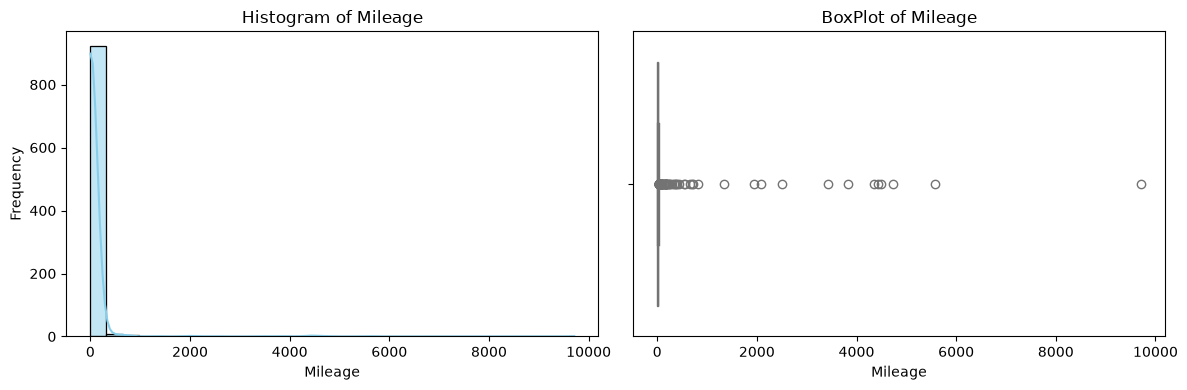

In [3]:
#Creating a function to Visualize the Null Values in the Data
def plot_hist_box(column_data,column_name=None):
    if column_name is None : column_name = column_data.name 
    plt.figure(figsize=(12,4))
    #Histogram 
    plt.subplot(1,2,1)
    sns.histplot(column_data,kde=True,bins=30,color='skyblue')
    plt.title(f"Histogram of {column_name}")
    plt.xlabel(column_name)
    plt.ylabel("Frequency")
    #Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=column_data,color='lightgreen')
    plt.title(f"BoxPlot of {column_name}")
    plt.xlabel(column_name)
    
    plt.tight_layout()
    plt.show()
plot_hist_box(df['mileage'], 'Mileage')

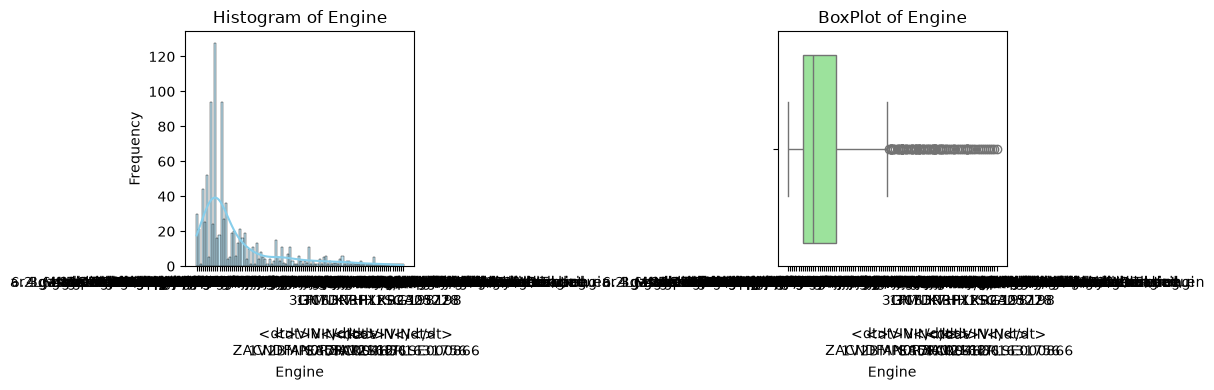

In [4]:
plot_hist_box(df['engine'], 'Engine')

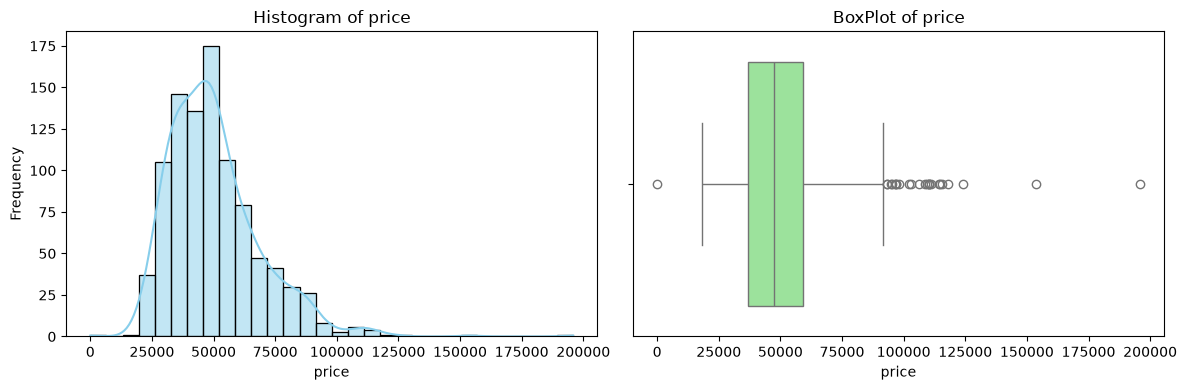

In [5]:
plot_hist_box(df['price'], 'price')

# Handing Null Values 

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, 'Jeep'),
  Text(1, 0, 'GMC'),
  Text(2, 0, 'Dodge'),
  Text(3, 0, 'RAM'),
  Text(4, 0, 'Nissan'),
  Text(5, 0, 'Ford'),
  Text(6, 0, 'Hyundai'),
  Text(7, 0, 'Chevrolet'),
  Text(8, 0, 'Volkswagen'),
  Text(9, 0, 'Chrysler'),
  Text(10, 0, 'Kia'),
  Text(11, 0, 'Mazda'),
  Text(12, 0, 'Acura'),
  Text(13, 0, 'Subaru'),
  Text(14, 0, 'Audi'),
  Text(15, 0, 'BMW'),
  Text(16, 0, 'Toyota'),
  Text(17, 0, 'Buick'),
  Text(18, 0, 'Mercedes-Benz'),
  Text(19, 0, 'Honda'),
  Text(20, 0, 'Lincoln'),
  Text(21, 0, 'Cadillac'),
  Text(22, 0, 'INFINITI'),
  Text(23, 0, 'Lexus'),
  Text(24, 0, 'Land Rover'),
  Text(25, 0, 'Volvo'),
  Text(26, 0, 'Genesis'),
  Text(27, 0, 'Jaguar')])

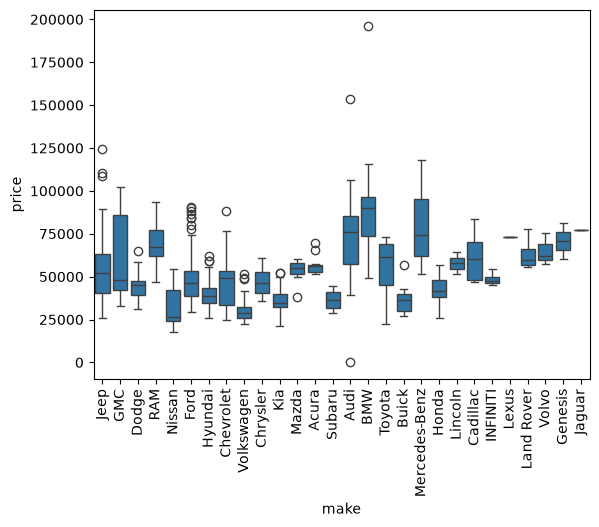

In [6]:
#Mileage 
df['mileage'] =df['mileage'].fillna(df['mileage'].median())
#Price
data = df.dropna(subset=['price'])
#fuel [Categorical data]
data['fuel'] = data['fuel'].fillna(data['fuel'].mode()[0])
data.groupby('make')['cylinders'].value_counts().reset_index(name='count')
# Cylinders
cylinder_mode_per_make = data.groupby('make')['cylinders'].apply(lambda x :x.mode()).droplevel(level=None).to_dict()
cylinder_mode_per_make
data['cylinders'] = data['cylinders'].fillna(data['make'].map(cylinder_mode_per_make))
data['cylinders'] = data['cylinders'].fillna(data['make'].map(cylinder_mode_per_make)).fillna(4)
#Interior color 
data['interior_color'] = data['interior_color'].fillna(data['interior_color'].mode()[0])
#doors 
data['doors'] = data['doors'].fillna(data['doors'].mode()[0])
#Exterior_color
data['exterior_color'] = data['exterior_color'].fillna(data['exterior_color'].mode()[0])
# Drop sum columns from data 
data = data.dropna(subset=['transmission','trim','body','engine'])
data.shape
#Visualize the price distribution by make using a boxplot
sns.boxplot(x='make',y='price',data=data)
plt.xticks(rotation=90)

In [7]:
data.drop(columns = ['name','description','exterior_color','interior_color'],inplace=True)
data.head(3)

,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain
0,Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,Four-wheel Drive
1,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Four-wheel Drive
2,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Four-wheel Drive


In [8]:
#splitting data by using variables 
x = data.drop(columns='price')
y = data['price']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,shuffle=True,random_state=42)
print(f"The X train Shape are ==> {x_train.shape}")
print(f"The X Test Shape are ==> {x_test.shape}")
# Check Categorrical columns 
categorical_columns = x_train.select_dtypes(include='object').columns.tolist()
categorical_columns
# Check unique values 
for col in categorical_columns:
    print(col)
    print(x_train[col].value_counts())
    print("======="*20)

The X train Shape are ==> (757, 12)
The X Test Shape are ==> (190, 12)
make
make
Jeep             151
Hyundai          101
Dodge             78
Ford              67
RAM               56
Chevrolet         42
Kia               41
Nissan            31
Mazda             28
Volkswagen        27
Mercedes-Benz     21
BMW               16
Honda             15
GMC               15
Audi              12
Cadillac           9
Chrysler           8
Subaru             8
Acura              7
Buick              6
Toyota             5
INFINITI           3
Land Rover         3
Volvo              2
Lincoln            2
Genesis            2
Lexus              1
Name: count, dtype: int64
model
model
Hornet             48
3500               37
Compass            34
Tucson Hybrid      26
Durango            25
                   ..
SQ8 e-tron          1
Ranger              1
Discovery Sport     1
AMG GLE 53          1
Sonata              1
Name: count, Length: 140, dtype: int64
engine
engine
16V GDI DOHC Turbo 

C:\Users\Alhou\AppData\Local\Temp\ipykernel_14356\271629980.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x_train.select_dtypes(include='object').columns.tolist()


# Apply Encoder for this data

In [9]:
from sklearn.preprocessing import OneHotEncoder
oht_drivetrain = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoded_values=oht_drivetrain.fit_transform(x_train[['drivetrain']])
encoded_cols = oht_drivetrain.get_feature_names_out().tolist()
print(encoded_cols)
print("================================================================")
#Convert drivetrain data to dataframe
encoded_df = pd.DataFrame(data=encoded_values,columns=encoded_cols,index=x_train.index) 
encoded_df.head(3)

['drivetrain_All-wheel Drive', 'drivetrain_Four-wheel Drive', 'drivetrain_Front-wheel Drive', 'drivetrain_Rear-wheel Drive']


,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive
111,1.0,0.0,0.0,0.0
78,0.0,1.0,0.0,0.0
578,1.0,0.0,0.0,0.0


In [10]:
#Concatenate the encoded dataframe with the original x_train dataframe
x_train = pd.concat([x_train,encoded_df],axis=1)
x_train.drop(columns='drivetrain',inplace=True)
x_train.head(3)

,make,model,year,engine,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive
111,Hyundai,Tucson Hybrid,2024,16V GDI DOHC Turbo Hybrid,4.0,Hybrid,5.0,6-Speed Automatic,SEL Convenience,SUV,4.0,1.0,0.0,0.0,0.0
78,RAM,3500,2024,24V DDI OHV Turbo Diesel,6.0,Diesel,13.0,Automatic,Tradesman,Pickup Truck,4.0,0.0,1.0,0.0,0.0
578,Chevrolet,Equinox,2024,"4 gasoline direct injection, DOHC, variable va...",4.0,Gasoline,3.0,Automatic,LS,SUV,4.0,1.0,0.0,0.0,0.0


# Apply Ordinal encoding 

In [11]:
cat_cols = x_train.select_dtypes(include='object').columns.tolist()
print("The Categorical Columns are : ",cat_cols)
print("=="*20)
# Check fuel column unique values
x_train['fuel'].value_counts()
# Check body column unique values
x_train['body'].value_counts()
x_train['make'].value_counts()
from sklearn.preprocessing import OrdinalEncoder
columns_encoder = OrdinalEncoder()
# Check x_train data 
x_train[['body','fuel','make']].head(3)

The Categorical Columns are :  ['make', 'model', 'engine', 'fuel', 'transmission', 'trim', 'body']


C:\Users\Alhou\AppData\Local\Temp\ipykernel_14356\542910465.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x_train.select_dtypes(include='object').columns.tolist()


,body,fuel,make
111,SUV,Hybrid,Hyundai
78,Pickup Truck,Diesel,RAM
578,SUV,Gasoline,Chevrolet


In [12]:
x_train[['body','fuel','make']] = columns_encoder.fit_transform(x_train[['body','fuel','make']])
x_train[['body','fuel','make']].head(3)

,body,fuel,make
111,6.0,4.0,12.0
78,5.0,0.0,22.0
578,6.0,3.0,5.0


In [13]:
for col,cat in zip(['body','fuel','make'],columns_encoder.categories_):
    print(f"Column : {col} , Categories : {cat}")
    for i,category in enumerate(cat):
        print(f"Category : {category} , Encoded Value : {i}")
    print("=="*20)

Column : body , Categories : ['Cargo Van' 'Convertible' 'Hatchback' 'Minivan' 'Passenger Van'
 'Pickup Truck' 'SUV' 'Sedan']
Category : Cargo Van , Encoded Value : 0
Category : Convertible , Encoded Value : 1
Category : Hatchback , Encoded Value : 2
Category : Minivan , Encoded Value : 3
Category : Passenger Van , Encoded Value : 4
Category : Pickup Truck , Encoded Value : 5
Category : SUV , Encoded Value : 6
Category : Sedan , Encoded Value : 7
Column : fuel , Categories : ['Diesel' 'E85 Flex Fuel' 'Electric' 'Gasoline' 'Hybrid'
 'PHEV Hybrid Fuel']
Category : Diesel , Encoded Value : 0
Category : E85 Flex Fuel , Encoded Value : 1
Category : Electric , Encoded Value : 2
Category : Gasoline , Encoded Value : 3
Category : Hybrid , Encoded Value : 4
Category : PHEV Hybrid Fuel , Encoded Value : 5
Column : make , Categories : ['Acura' 'Audi' 'BMW' 'Buick' 'Cadillac' 'Chevrolet' 'Chrysler' 'Dodge'
 'Ford' 'GMC' 'Genesis' 'Honda' 'Hyundai' 'INFINITI' 'Jeep' 'Kia'
 'Land Rover' 'Lexus' 'Linc

<Axes: xlabel='price', ylabel='Density'>

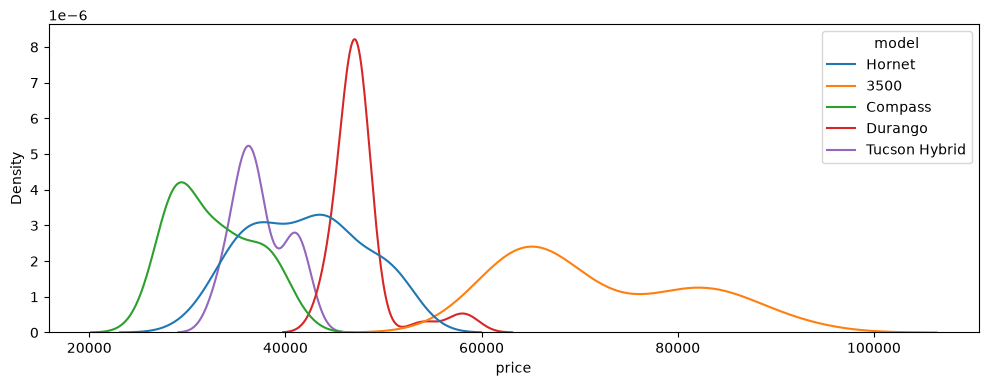

In [14]:
#Visualize for check columns effects on the price column
plt.figure(figsize=(12,4))
sns.kdeplot(data=data,x="price",hue='model',hue_order=data['model'].value_counts().index[:5])

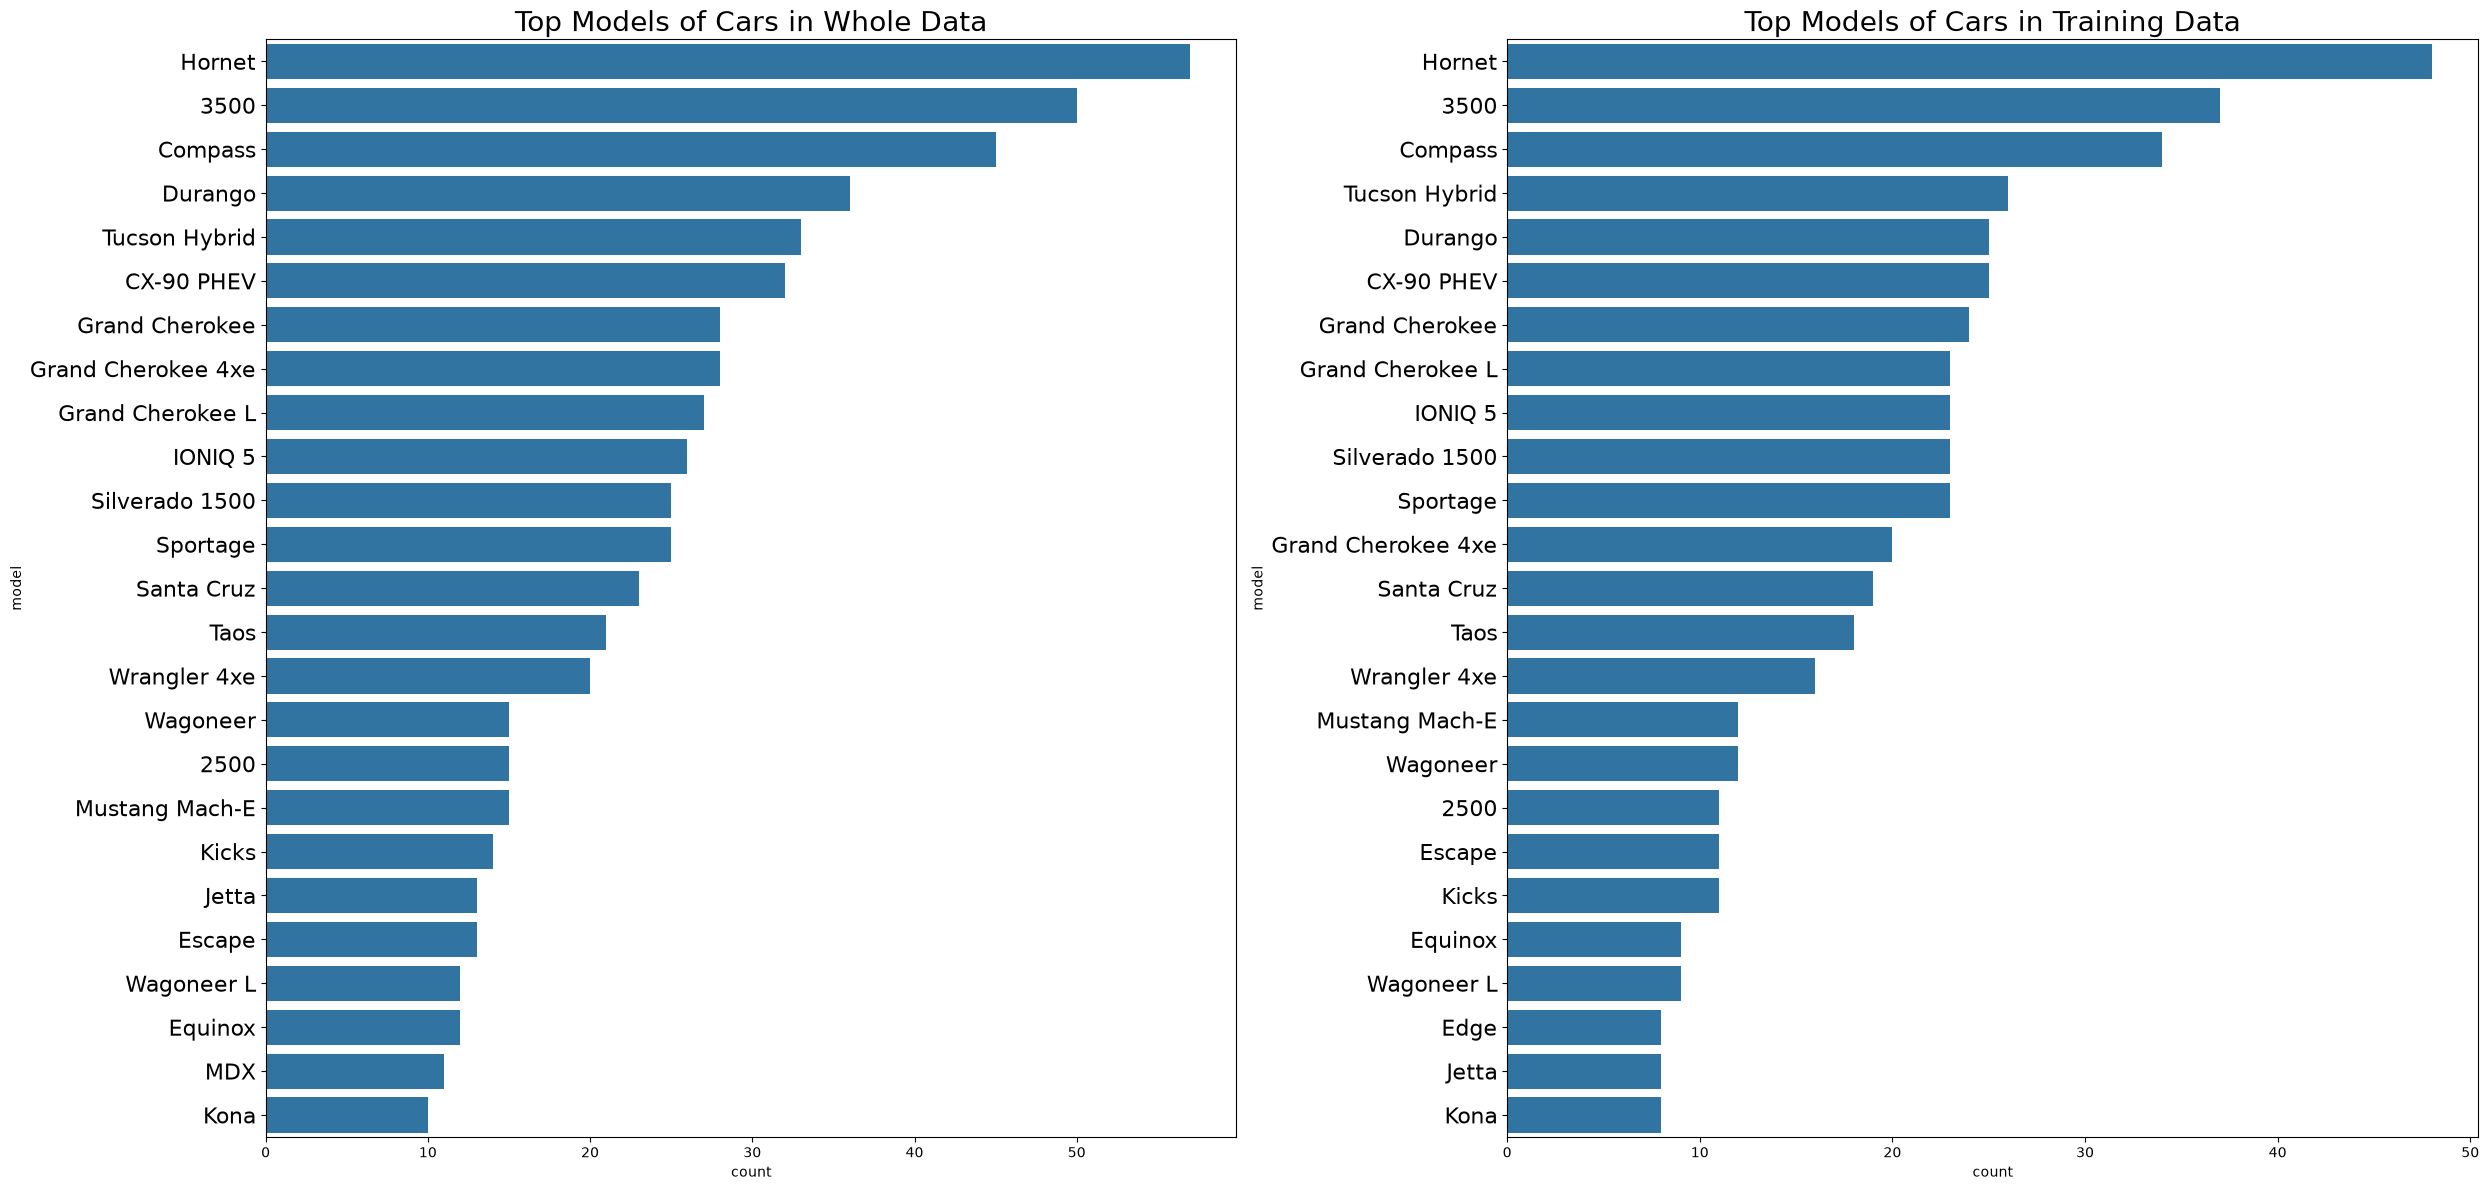

In [15]:
plt.figure(figsize=(25, 12))

# First subplot
plt.subplot(1, 2, 1)
sns.countplot(data=data, y='model', order=data['model'].value_counts().index[:25])
plt.yticks(fontsize=16)
plt.title('Top Models of Cars in Whole Data', fontsize=20)

# Second subplot
plt.subplot(1, 2, 2)
sns.countplot(data=x_train, y='model', order=x_train['model'].value_counts().index[:25])
plt.yticks(fontsize=16)
plt.title('Top Models of Cars in Training Data', fontsize=20)

plt.tight_layout();

In [16]:
top_models= x_train['model'].value_counts().nlargest(25).index
x_train['model']=x_train['model'].where(x_train['model'].isin(top_models),'other')
x_train['model']

111       Tucson Hybrid
78                 3500
578             Equinox
893               other
84     Grand Cherokee L
             ...       
108             Compass
278          CX-90 PHEV
911            Sportage
455                2500
104      Silverado 1500
Name: model, Length: 757, dtype: object

# `Task` 
# Apply one hot encoding for model column

In [17]:
x_train['model'] = x_train['model'].astype(str)
oht_model = OneHotEncoder(sparse_output=False)
encoded_values = oht_model.fit_transform(x_train[['model']])
encoded_cols = oht_model.get_feature_names_out().tolist()
#Convert model column to DataFrame
encoded_df = pd.DataFrame(data=encoded_values,columns=encoded_cols,index=x_train.index)
#Concatenate the encoded DataFrame with the original x_train DataFrame
x_train = pd.concat([x_train,encoded_df],axis=1)
#drop the original model column from the x_train DataFrame
x_train.drop(columns=['model'], inplace=True)
x_train.head(3)

,make,year,engine,cylinders,fuel,mileage,transmission,trim,body,doors,...,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other
111,12.0,2024,16V GDI DOHC Turbo Hybrid,4.0,4.0,5.0,6-Speed Automatic,SEL Convenience,6.0,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
78,22.0,2024,24V DDI OHV Turbo Diesel,6.0,0.0,13.0,Automatic,Tradesman,5.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
578,5.0,2024,"4 gasoline direct injection, DOHC, variable va...",4.0,3.0,3.0,Automatic,LS,6.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Apply Encoding for engine column

In [18]:
x_train['engine'].unique()

<StringArray>
[                                '16V GDI DOHC Turbo Hybrid',
                                  '24V DDI OHV Turbo Diesel',
 '4 gasoline direct injection, DOHC, variable valve control',
      'd>\n\n    \n    <dt>VIN</dt>\n     7FARS4H71SE000866',
                                                       'OHV',
 'ce 5.6L V-8 gasoline direct injection, DOHC, variable val',
                                       '16V GDI DOHC Hybrid',
                                                         'c',
                                        '16V PDI DOHC Turbo',
  '6.2L V-8 gasoline direct injection, variable valve contr',
                                               '16V GDI OHV',
 'gasoline direct injection, DOHC, intercooled turbo, premi',
                                             '24V MPFI DOHC',
                                              '16V MPFI OHV',
 'DOHC, D-CVVT variable valve control, regular unleaded, en',
                           'oled Turbo Diesel I-6 6.7 L/

In [19]:
# Apply feature engineering 
x_train['engine']= x_train['engine'].astype(str).str.lower() # First convert data to lowercase 
# Extract features from engine column
x_train['is_turbo'] = x_train['engine'].apply(lambda x:1 if 'turbo' in x or 'ecoboost' in x else 0)
x_train['is_hybrid'] = x_train['engine'].apply(lambda x:1 if 'hybrid' in x else 0)
x_train['is_diesel'] = x_train['engine'].apply(lambda x:1 if 'diesel' in x else 0)

#Extract the valve type from engine column
def get_valve_type(text):
    if 'dohc' in text: return 'DOHC'
    if 'ohv' in text: return 'OHV'
    if 'sohc' in text: return 'SOHC'
    return 'Other' # For corrupted texts and VIN codes
x_train['valve_type'] = x_train['engine'].apply(get_valve_type)

# After apply feature engineering and preprocessing for engine column , and extract features

In [20]:
def extract_engine_features(engine_str):
    engine_str = str(engine_str).lower()  # Convert to lowercase for consistency
    return {
        "is_v6" : int('v-6' in engine_str or '3.61' in engine_str),
        "is_v8" : int('v-8' in engine_str or '5.0' in engine_str),
        "is_i4" : int('i-4' in engine_str or '2.01' in engine_str),
        "is_turbo" : int('turbo' in engine_str),
        'is_hybrid': int('hybrid' in engine_str),
        'is_diesel': int('diesel' in engine_str),
        'is_electric': int('electric' in engine_str or 'zev' in engine_str or 'ev' in engine_str),
        'valves_16v': int('16v' in engine_str),
        'valves_24v': int('24v' in engine_str),
        'valves_12v': int('12v' in engine_str),
        'is_dohc': int('dohc' in engine_str),
        'is_sohc': int('sohc' in engine_str),
        'is_ohv': int('ohv' in engine_str),
        'has_vvt': int('vvt' in engine_str)
    }
x_train['engine'].apply(extract_engine_features).apply(pd.Series)

,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt
111,0,0,0,1,1,0,0,1,0,0,1,0,0,0
78,0,0,0,1,0,1,0,0,1,0,0,0,1,0
578,0,0,0,0,0,0,0,0,0,0,1,0,0,0
893,0,0,0,0,0,0,0,0,0,0,0,0,0,0
84,0,0,0,0,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,0,0,0,0,0,0,0,0,0,0,1,0,0,0
278,0,0,0,0,0,0,1,1,0,0,1,0,0,0
911,0,0,0,0,0,0,0,1,0,0,1,0,0,0
455,0,0,0,0,0,0,0,1,0,0,0,0,1,0


In [21]:
engine_features_train = x_train['engine'].apply(extract_engine_features).apply(pd.Series)
engine_features_train.head(3)

,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt
111,0,0,0,1,1,0,0,1,0,0,1,0,0,0
78,0,0,0,1,0,1,0,0,1,0,0,0,1,0
578,0,0,0,0,0,0,0,0,0,0,1,0,0,0


# Append to your dataset

In [22]:
x_train = pd.concat([x_train,engine_features_train],axis=1)
x_train = x_train.drop(columns=['engine'])
x_train.head(3)

,make,year,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain_All-wheel Drive,...,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt
111,12.0,2024,4.0,4.0,5.0,6-Speed Automatic,SEL Convenience,6.0,4.0,1.0,...,1,0,0,1,0,0,1,0,0,0
78,22.0,2024,6.0,0.0,13.0,Automatic,Tradesman,5.0,4.0,0.0,...,0,1,0,0,1,0,0,0,1,0
578,5.0,2024,4.0,3.0,3.0,Automatic,LS,6.0,4.0,1.0,...,0,0,0,0,0,0,1,0,0,0


In [23]:
# To show all columns
pd.set_option('display.max_columns', None)
x_train.head(3)

,make,year,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt
111,12.0,2024,4.0,4.0,5.0,6-Speed Automatic,SEL Convenience,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0
78,22.0,2024,6.0,0.0,13.0,Automatic,Tradesman,5.0,4.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0
578,5.0,2024,4.0,3.0,3.0,Automatic,LS,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0


# Transmission Column

In [24]:
x_train['transmission'].unique()

<StringArray>
[                          '6-Speed Automatic',
                                   'Automatic',
                               'Automatic CVT',
                           '8-Speed Automatic',
           '8-Speed Automatic with Auto-Shift',
                           '8-speed automatic',
                          '10-Speed Automatic',
                           '9-Speed Automatic',
                           '1-Speed Automatic',
                     '9-Speed 948TE Automatic',
                     'Aisin 6-Speed Automatic',
                                    'Variable',
                                         'CVT',
                  '7-Speed Automatic S tronic',
        '7-Speed DSG Automatic with Tiptronic',
           '7-Speed Automatic with Auto-Shift',
 '6-Speed Automatic Electronic with Overdrive',
                           '6-SPEED AUTOMATIC',
                            'CVT with Xtronic',
                                 '8-Speed A/T',
              '7-Speed DSG

In [25]:
def extract_trans_type(transmission_str):
    transmission_str = str(transmission_str).lower()  # Convert to lowercase for consistency
    if 'manual' in transmission_str: return 'Manual'
    elif 'cvt' in transmission_str or 'variable' in transmission_str: return 'CVT'
    elif 'auto' in transmission_str or 'a/t' in transmission_str: return 'Automatic'
    else: return 'Other'
x_train['trans_type'] = x_train['transmission'].apply(extract_trans_type)
print(x_train['trans_type'].value_counts())
x_train.head(3)

trans_type
Automatic    711
CVT           45
Other          1
Name: count, dtype: int64


,make,year,cylinders,fuel,mileage,transmission,trim,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type
111,12.0,2024,4.0,4.0,5.0,6-Speed Automatic,SEL Convenience,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0,Automatic
78,22.0,2024,6.0,0.0,13.0,Automatic,Tradesman,5.0,4.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0,Automatic
578,5.0,2024,4.0,3.0,3.0,Automatic,LS,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0,Automatic


In [26]:
# I need to seperate number for speed 
# Used Regular Expression to extract the number from the string
import re
def extract_trans_speed(val):
    val = str(val).lower() 
    match = re.search(r'(\d+)[ -]?Speed',val,re.IGNORECASE)
    return int(match.group(1)) if match else -1 
x_train['trans_speed'] = x_train['transmission'].apply(extract_trans_speed)
x_train= x_train.drop(columns=['transmission']) #drop the transmission column after extracting the features
x_train.head(3)

,make,year,cylinders,fuel,mileage,trim,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed
111,12.0,2024,4.0,4.0,5.0,SEL Convenience,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0,Automatic,6
78,22.0,2024,6.0,0.0,13.0,Tradesman,5.0,4.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0,Automatic,-1
578,5.0,2024,4.0,3.0,3.0,LS,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0,Automatic,-1


In [27]:
# To Show all columns
x_train.columns

Index(['make', 'year', 'cylinders', 'fuel', 'mileage', 'trim', 'body', 'doors',
       'drivetrain_All-wheel Drive', 'drivetrain_Four-wheel Drive',
       'drivetrain_Front-wheel Drive', 'drivetrain_Rear-wheel Drive',
       'model_2500', 'model_3500', 'model_CX-90 PHEV', 'model_Compass',
       'model_Durango', 'model_Edge', 'model_Equinox', 'model_Escape',
       'model_Grand Cherokee', 'model_Grand Cherokee 4xe',
       'model_Grand Cherokee L', 'model_Hornet', 'model_IONIQ 5',
       'model_Jetta', 'model_Kicks', 'model_Kona', 'model_Mustang Mach-E',
       'model_Santa Cruz', 'model_Silverado 1500', 'model_Sportage',
       'model_Taos', 'model_Tucson Hybrid', 'model_Wagoneer',
       'model_Wagoneer L', 'model_Wrangler 4xe', 'model_other', 'is_turbo',
       'is_hybrid', 'is_diesel', 'valve_type', 'is_v6', 'is_v8', 'is_i4',
       'is_turbo', 'is_hybrid', 'is_diesel', 'is_electric', 'valves_16v',
       'valves_24v', 'valves_12v', 'is_dohc', 'is_sohc', 'is_ohv', 'has_vvt',
      

# Applying features Engineering for `Trim` column

In [28]:
print("The Number of Unique Values in Trim Column are : ",x_train['trim'].nunique())
x_train['trim'].value_counts().nlargest(30)

The Number of Unique Values in Trim Column are :  171


trim
Limited            56
Base               42
SEL                28
Premium            24
Latitude           20
Pursuit            20
Tradesman          18
1.5T SE            15
Laredo             15
R/T Plus           13
GT                 13
SEL Convenience    12
SV                 11
LT                 11
Sport              11
R/T                11
S                  11
XLT                11
Series II          11
Laramie            10
Rubicon            10
SE                  9
GT AWD              9
EX                  9
Altitude            8
SR                  8
Trailhawk           8
X-Line              8
Premium Plus        7
Base 4MATIC         7
Name: count, dtype: int64

In [29]:
x_train['trim'].unique()

<StringArray>
[              'SEL Convenience',                     'Tradesman',
                            'LS',                          'EX-L',
                       'Limited',                            'SV',
                           'SEL',                    '2.5T NIGHT',
                        'Denali',                            'LT',
 ...
                    'Wilderness',                'X-Pro Prestige',
                    'King Ranch',                 'Standard Roof',
 'Tradesman/SLT/Laramie/Limited',                           'ZR2',
                   'Sport w/1SJ',                            'SL',
                            'XL',                   'Crew 144 WB']
Length: 171, dtype: str

In [30]:
x_train['trim'].value_counts()

trim
Limited        56
Base           42
SEL            28
Premium        24
Latitude       20
               ..
ZR2             1
Sport w/1SJ     1
SL              1
XL              1
Crew 144 WB     1
Name: count, Length: 171, dtype: int64

# Create a fucntion to simplify Trim column

In [33]:
def simplify_trim(trim_str):
    trim_str = str(trim_str).lower() # convert to lowercase for consistency
    if 'sel' in trim_str: return 'SEL'
    elif 'se' in trim_str: return 'SE'
    elif 'rt' in trim_str: return 'R/T'
    elif 'base' in trim_str: return 'Base'
    elif 'limited' in trim_str: return 'Limited'
    elif 'premium' in trim_str: return 'Premium'
    elif 'latitude' in trim_str: return 'Latitude'
    elif 'sport' in trim_str: return 'Sport'
    elif 'laredo' in trim_str: return 'Laredo'
    elif 'xlt' in trim_str: return 'XLT'
    elif 'platinum' in trim_str: return 'Platinum'
    elif 's' in trim_str: return 'S'
    elif 'xle' in trim_str: return 'XLE'
    elif 'limited' in trim_str: return 'Limited'
    elif 'touring' in trim_str: return 'Touring'
    elif 'luxury' in trim_str: return 'Luxury'
    elif 'sport' in trim_str: return 'Sport'
    elif 'premium' in trim_str: return 'Premium'
    elif 'grand' in trim_str: return 'Grand'
    elif 'trailhawk' in trim_str: return 'Trailhawk'
    else: return 'Other'
x_train['trim_simplified'] = x_train['trim'].apply(simplify_trim)
print("the Number of Unique Values in trim_simplified:", x_train['trim_simplified'].nunique())
#drop the original trim column after simplification
x_train = x_train.drop(columns=['trim'])
x_train.head()

the Number of Unique Values in trim_simplified: 14


,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified
111,12.0,2024,4.0,4.0,5.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0,Automatic,6,SEL
78,22.0,2024,6.0,0.0,13.0,5.0,4.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0,Automatic,-1,S
578,5.0,2024,4.0,3.0,3.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0,Automatic,-1,S
893,11.0,2025,4.0,3.0,0.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0,Other,0,0,0,0,0,0,0,0,0,0,0,0,0,0,CVT,-1,Other
84,14.0,2024,6.0,3.0,8.0,6.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,OHV,0,0,0,0,0,0,0,0,0,0,0,0,1,0,Automatic,8,Limited


In [34]:
pd.set_option('display.max_columns',None)
x_train.head()

,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified
111,12.0,2024,4.0,4.0,5.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,0,DOHC,0,0,0,1,1,0,0,1,0,0,1,0,0,0,Automatic,6,SEL
78,22.0,2024,6.0,0.0,13.0,5.0,4.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,OHV,0,0,0,1,0,1,0,0,1,0,0,0,1,0,Automatic,-1,S
578,5.0,2024,4.0,3.0,3.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,DOHC,0,0,0,0,0,0,0,0,0,0,1,0,0,0,Automatic,-1,S
893,11.0,2025,4.0,3.0,0.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0,Other,0,0,0,0,0,0,0,0,0,0,0,0,0,0,CVT,-1,Other
84,14.0,2024,6.0,3.0,8.0,6.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,OHV,0,0,0,0,0,0,0,0,0,0,0,0,1,0,Automatic,8,Limited


In [36]:
# Encoding Categorical Data 
categorical_columns = x_train.select_dtypes(include='object').columns.tolist()
categorical_columns

C:\Users\Alhou\AppData\Local\Temp\ipykernel_14356\3001162110.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = x_train.select_dtypes(include='object').columns.tolist()


['valve_type', 'trans_type', 'trim_simplified']

In [37]:
x_train[categorical_columns]

,valve_type,trans_type,trim_simplified
111,DOHC,Automatic,SEL
78,OHV,Automatic,S
578,DOHC,Automatic,S
893,Other,CVT,Other
84,OHV,Automatic,Limited
...,...,...,...
108,DOHC,Automatic,Latitude
278,DOHC,Automatic,Premium
911,DOHC,Automatic,S
455,OHV,Automatic,S


In [38]:
cols_encoder = OrdinalEncoder()
x_train[categorical_columns] = cols_encoder.fit_transform(x_train[categorical_columns])
x_train.head()

,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_turbo,is_hybrid,is_diesel,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified
111,12.0,2024,4.0,4.0,5.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,0,0.0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,0.0,6,10.0
78,22.0,2024,6.0,0.0,13.0,5.0,4.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,1.0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0.0,-1,8.0
578,5.0,2024,4.0,3.0,3.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.0,-1,8.0
893,11.0,2025,4.0,3.0,0.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,-1,4.0
84,14.0,2024,6.0,3.0,8.0,6.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,8,2.0


In [39]:
x_train[categorical_columns]

,valve_type,trans_type,trim_simplified
111,0.0,0.0,10.0
78,1.0,0.0,8.0
578,0.0,0.0,8.0
893,2.0,1.0,4.0
84,1.0,0.0,2.0
...,...,...,...
108,0.0,0.0,1.0
278,0.0,0.0,6.0
911,0.0,0.0,8.0
455,1.0,0.0,8.0



## 📏 What is **Scaling**?

**Scaling** is the process of **transforming features** so that they are on a **similar range or scale** often between 0–1 or -1 to 1.

It does **not** change the relationships between values; it just adjusts their magnitude.

---

## 🤔 Why and **When** Do You Need Scaling?

### ✅ You **need scaling** when:

| Situation                               | Reason                                                                                                                           |
| --------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| **Using distance-based models**         | Algorithms like **KNN**, **K-Means**, or **SVM** are sensitive to feature scale large values can dominate small ones.          |
| **Using gradient-based models**         | Models like **Logistic Regression**, **Linear Regression**, and **Neural Networks** converge faster and better with scaled data. |
| **Features have very different ranges** | Example: one feature ranges from 1–1000, another from 0–1, this skews the model learning.                                       |
| **You want to improve model stability** | Especially for **regularized models** like Lasso or Ridge.                                                                       |

---

## ❌ You usually **don’t need scaling** when:

* Using **tree-based models** like:

  * Decision Tree
  * Random Forest
  * XGBoost
  * LightGBM

These models are **not affected** by the scale of input features.

---

## 🛠️ Common Scaling Methods in Python (with `sklearn`)

| Method             | Description                                 | Use Case                                                  |
| ------------------ | ------------------------------------------- | --------------------------------------------------------- |
| **StandardScaler** | Scales to mean = 0, std = 1                 | Best for most models like Logistic/Linear Regression, SVM |
| **MinMaxScaler**   | Scales to range \[0, 1]                     | Useful when input is bounded or you want normalized data  |
| **RobustScaler**   | Uses median and IQR                         | Best when data has **outliers**                           |
| **MaxAbsScaler**   | Scales to \[-1, 1] using max absolute value | Best for sparse data (e.g. text)                          |
| **Normalizer**     | Scales each sample (row) to unit norm       | Used in text data or clustering                           |

---
### 📌 Important Note:

* **Apply scaling after train/test split** (fit on training data, transform both).
* Don’t scale **categorical features** unless they are encoded as numeric and meaningful.

---

## ✅ Summary Table:

| Method         | Handles Outliers? | Keeps Distribution?  | Range           |
| -------------- | ----------------- | -------------------- | --------------- |
| StandardScaler | ❌ No              | ✅ Yes                | Mean 0, Std 1   |
| MinMaxScaler   | ❌ No              | ❌ No                 | \[0, 1]         |
| RobustScaler   | ✅ Yes             | ✅ Yes (median-based) | Depends         |
| MaxAbsScaler   | ❌ No              | ❌ No                 | \[-1, 1]        |
| Normalizer     | ❌ No              | ❌ No                 | Vector norm = 1 |

# Apply Robust Scaling

# I need to show Ouliers , used -> `boxplot`

In [49]:
for col, categories in zip(categorical_columns, cols_encoder.categories_):
    print(f"Column: {col}")
    for i, category in enumerate(categories):
        print(f"  {category} → {i}")
    print('\n')

Column: valve_type
  DOHC → 0
  OHV → 1
  Other → 2
  SOHC → 3


Column: trans_type
  Automatic → 0
  CVT → 1
  Other → 2


Column: trim_simplified
  Laredo → 0
  Latitude → 1
  Limited → 2
  Luxury → 3
  Other → 4
  Platinum → 5
  Premium → 6
  R/T → 7
  S → 8
  SE → 9
  SEL → 10
  Touring → 11
  Trailhawk → 12
  XLT → 13




In [56]:
print(type(x_train))
print(x_train.shape)
print(x_train.columns[:10])
print(x_train.dtypes)

<class 'pandas.DataFrame'>
(757, 58)
Index(['make', 'year', 'cylinders', 'fuel', 'mileage', 'body', 'doors',
       'drivetrain_All-wheel Drive', 'drivetrain_Four-wheel Drive',
       'drivetrain_Front-wheel Drive'],
      dtype='str')
make                            float64
year                              int64
cylinders                       float64
fuel                            float64
mileage                         float64
body                            float64
doors                           float64
drivetrain_All-wheel Drive      float64
drivetrain_Four-wheel Drive     float64
drivetrain_Front-wheel Drive    float64
drivetrain_Rear-wheel Drive     float64
model_2500                      float64
model_3500                      float64
model_CX-90 PHEV                float64
model_Compass                   float64
model_Durango                   float64
model_Edge                      float64
model_Equinox                   float64
model_Escape                    float64
mode

In [58]:
print(x_train.columns[x_train.columns.duplicated()])
x_train = x_train.loc[:, ~x_train.columns.duplicated()]

Index(['is_turbo', 'is_hybrid', 'is_diesel'], dtype='str')


In [59]:
print(x_train.columns[x_train.columns.duplicated()])

Index([], dtype='str')


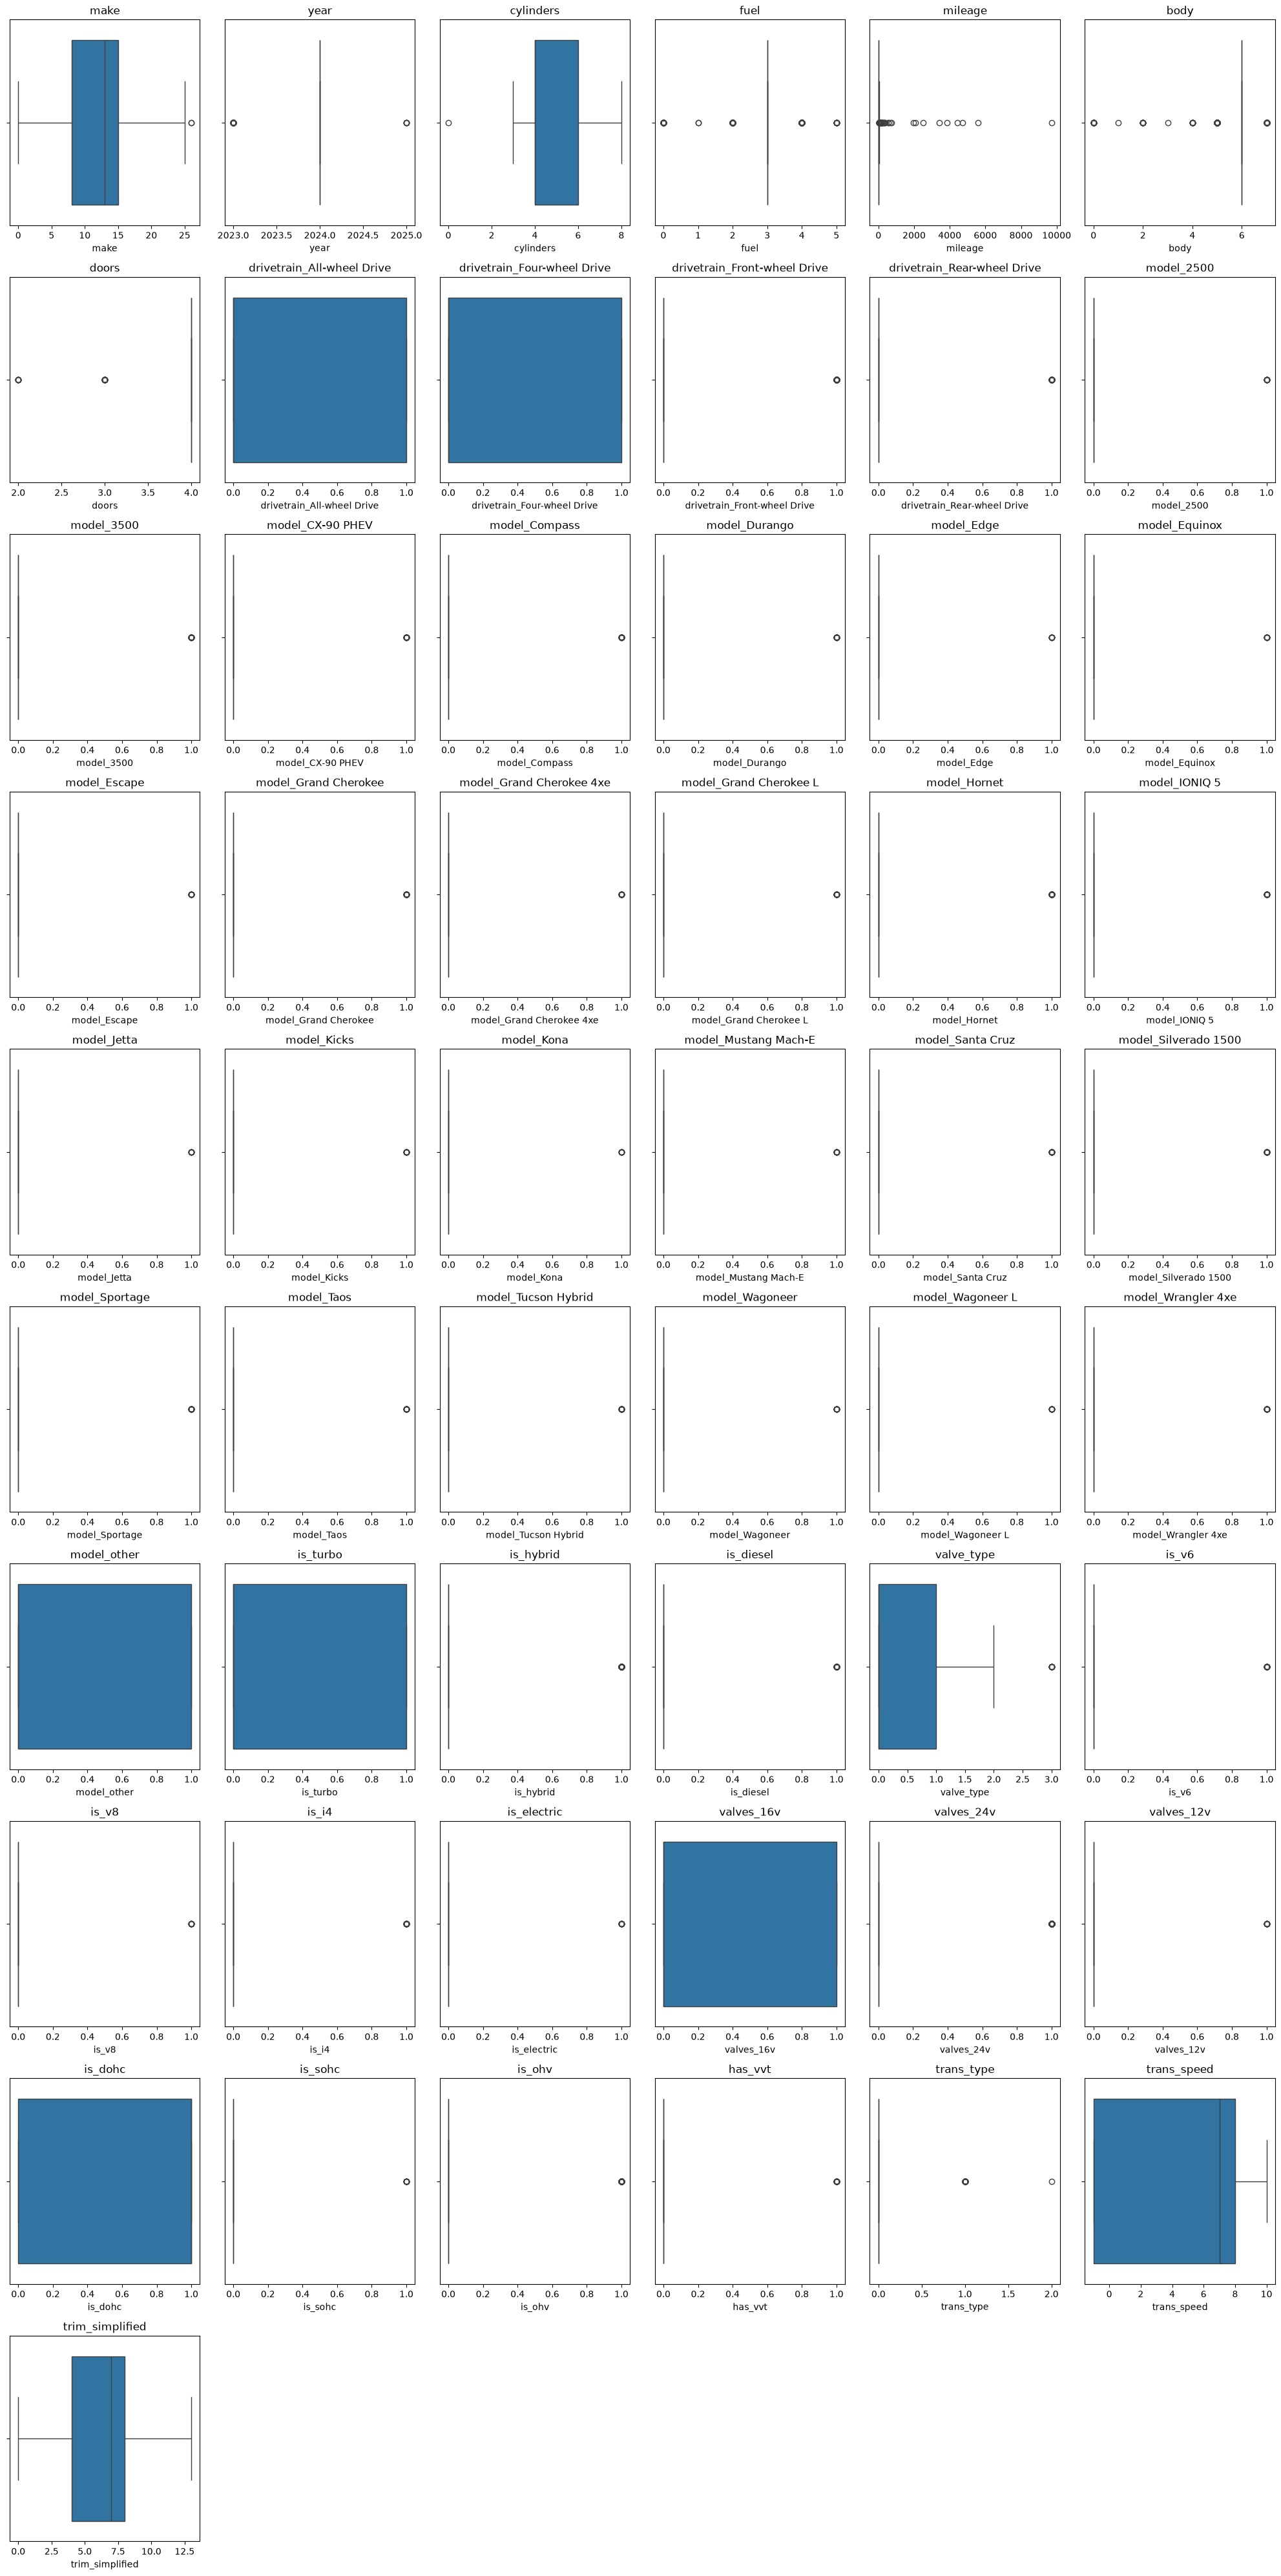

In [61]:
import math
n_cols = 6
n_rows = math.ceil(len(x_train.columns) / n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
ax = ax.flatten()
for i, col in enumerate(x_train.columns):
    sns.boxplot(x=x_train[col], ax=ax[i])
    ax[i].set_title(col)
for j in range(len(x_train.columns), len(ax)):
    ax[j].set_visible(False)
plt.tight_layout()
plt.show()

In [62]:
# Take copy from data 
x_scaled = x_train.copy()
x_scaled.sample(5)

,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified
510,22.0,2024,6.0,0.0,5.0,5.0,4.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,2.0,0,0,0,0,0,0,0,0,0,0,0,0.0,-1,8.0
948,14.0,2024,6.0,3.0,10.0,6.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,1,0,0.0,8,0.0
706,8.0,2024,4.0,3.0,48.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0.0,0,0,0,0,1,0,0,1,0,0,0,0.0,8,4.0
668,8.0,2024,6.0,3.0,8.0,5.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0,0.0,0,0,0,0,0,1,0,1,0,0,0,0.0,-1,8.0
914,19.0,2025,6.0,3.0,0.0,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0,2.0,0,0,0,0,0,0,0,0,0,0,0,0.0,8,6.0


In [63]:
from sklearn.preprocessing import RobustScaler
scalar = RobustScaler()
x_scaled[['year','cylinders','mileage','trans_speed']] = scalar.fit_transform(x_scaled[['year','cylinders','mileage','trans_speed']])
x_scaled

,make,year,cylinders,fuel,mileage,body,doors,drivetrain_All-wheel Drive,drivetrain_Four-wheel Drive,drivetrain_Front-wheel Drive,drivetrain_Rear-wheel Drive,model_2500,model_3500,model_CX-90 PHEV,model_Compass,model_Durango,model_Edge,model_Equinox,model_Escape,model_Grand Cherokee,model_Grand Cherokee 4xe,model_Grand Cherokee L,model_Hornet,model_IONIQ 5,model_Jetta,model_Kicks,model_Kona,model_Mustang Mach-E,model_Santa Cruz,model_Silverado 1500,model_Sportage,model_Taos,model_Tucson Hybrid,model_Wagoneer,model_Wagoneer L,model_Wrangler 4xe,model_other,is_turbo,is_hybrid,is_diesel,valve_type,is_v6,is_v8,is_i4,is_electric,valves_16v,valves_24v,valves_12v,is_dohc,is_sohc,is_ohv,has_vvt,trans_type,trans_speed,trim_simplified
111,12.0,0.0,0.0,4.0,-0.375,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1,1,0,0.0,0,0,0,0,1,0,0,1,0,0,0,0.0,-0.111111,10.0
78,22.0,0.0,1.0,0.0,0.625,5.0,4.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,1.0,0,0,0,0,0,1,0,0,0,1,0,0.0,-0.888889,8.0
578,5.0,0.0,0.0,3.0,-0.625,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0.0,-0.888889,8.0
893,11.0,1.0,0.0,3.0,-1.000,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0,2.0,0,0,0,0,0,0,0,0,0,0,0,1.0,-0.888889,4.0
84,14.0,0.0,1.0,3.0,0.000,6.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1.0,0,0,0,0,0,0,0,0,0,1,0,0.0,0.111111,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,14.0,0.0,0.0,3.0,-0.875,6.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0.0,-0.888889,1.0
278,19.0,0.0,0.0,5.0,0.125,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,1,1,0,0,1,0,0,0,0.0,-0.888889,6.0
911,15.0,0.0,0.0,3.0,-0.875,6.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,1,0,0,1,0,0,0,0.0,0.111111,8.0
455,22.0,0.0,2.0,3.0,-1.000,5.0,4.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1.0,0,0,0,0,1,0,0,0,0,1,0,0.0,0.111111,8.0


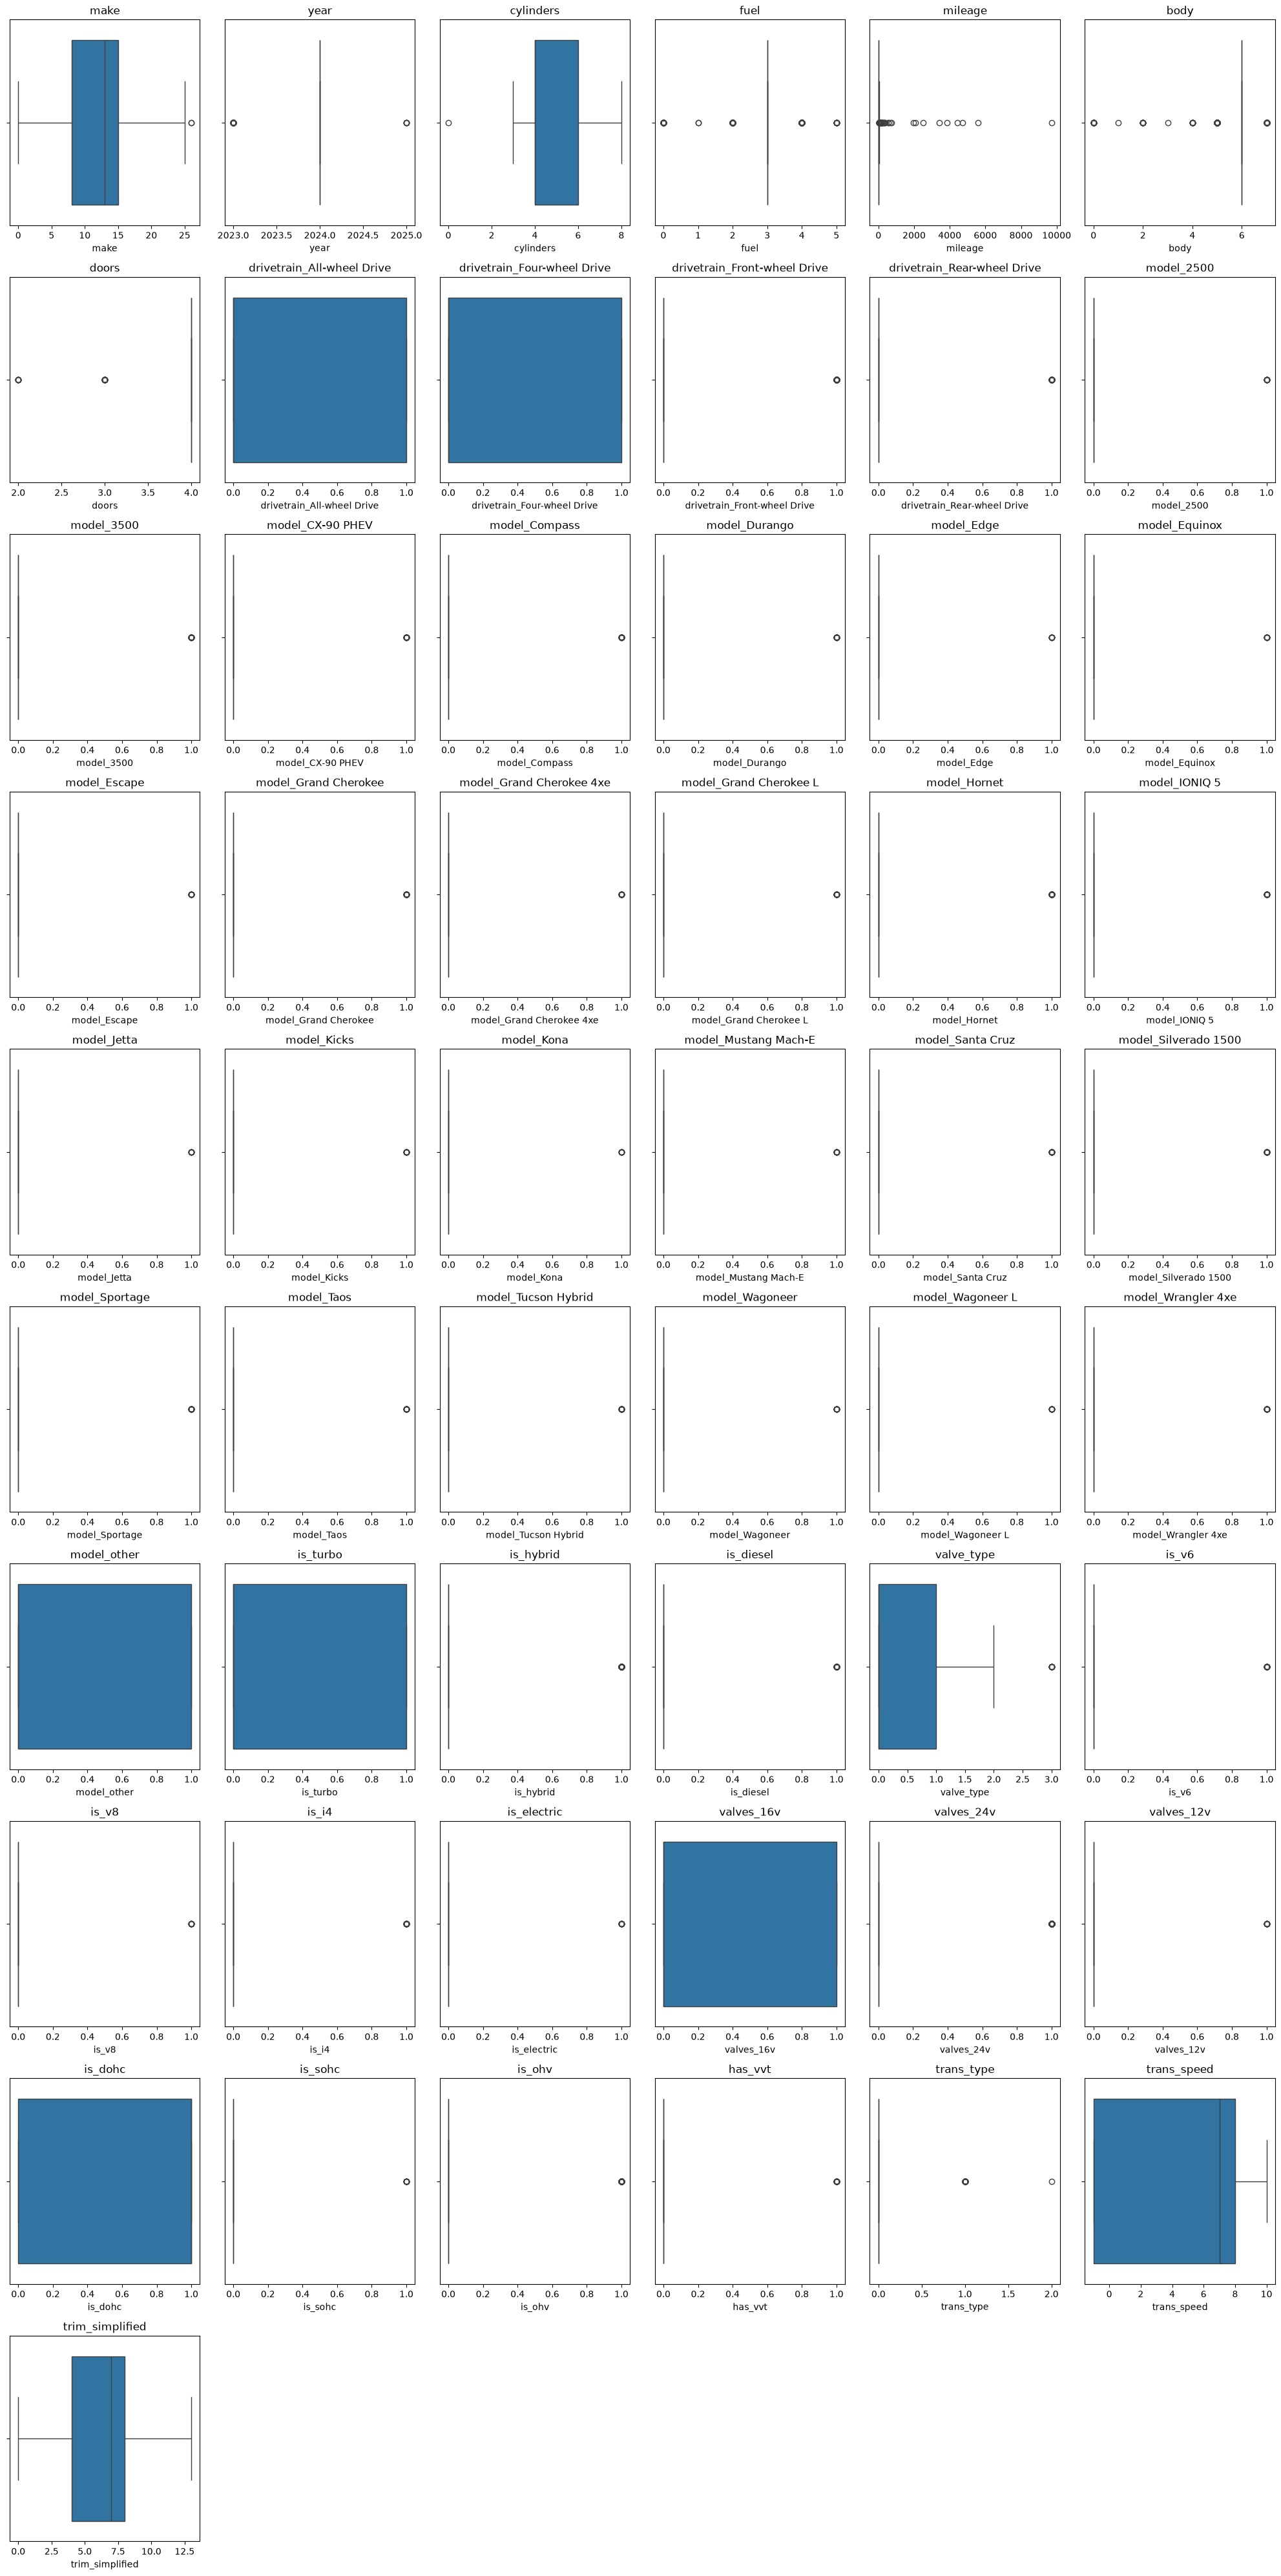

In [65]:
import math
n_cols = 6
n_rows = math.ceil(len(x_scaled.columns) / n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
ax = ax.flatten()
for i, col in enumerate(x_scaled.columns):
    sns.boxplot(x=x_train[col], ax=ax[i])
    ax[i].set_title(col)
for j in range(len(x_scaled.columns), len(ax)):
    ax[j].set_visible(False)
plt.tight_layout()
plt.show()

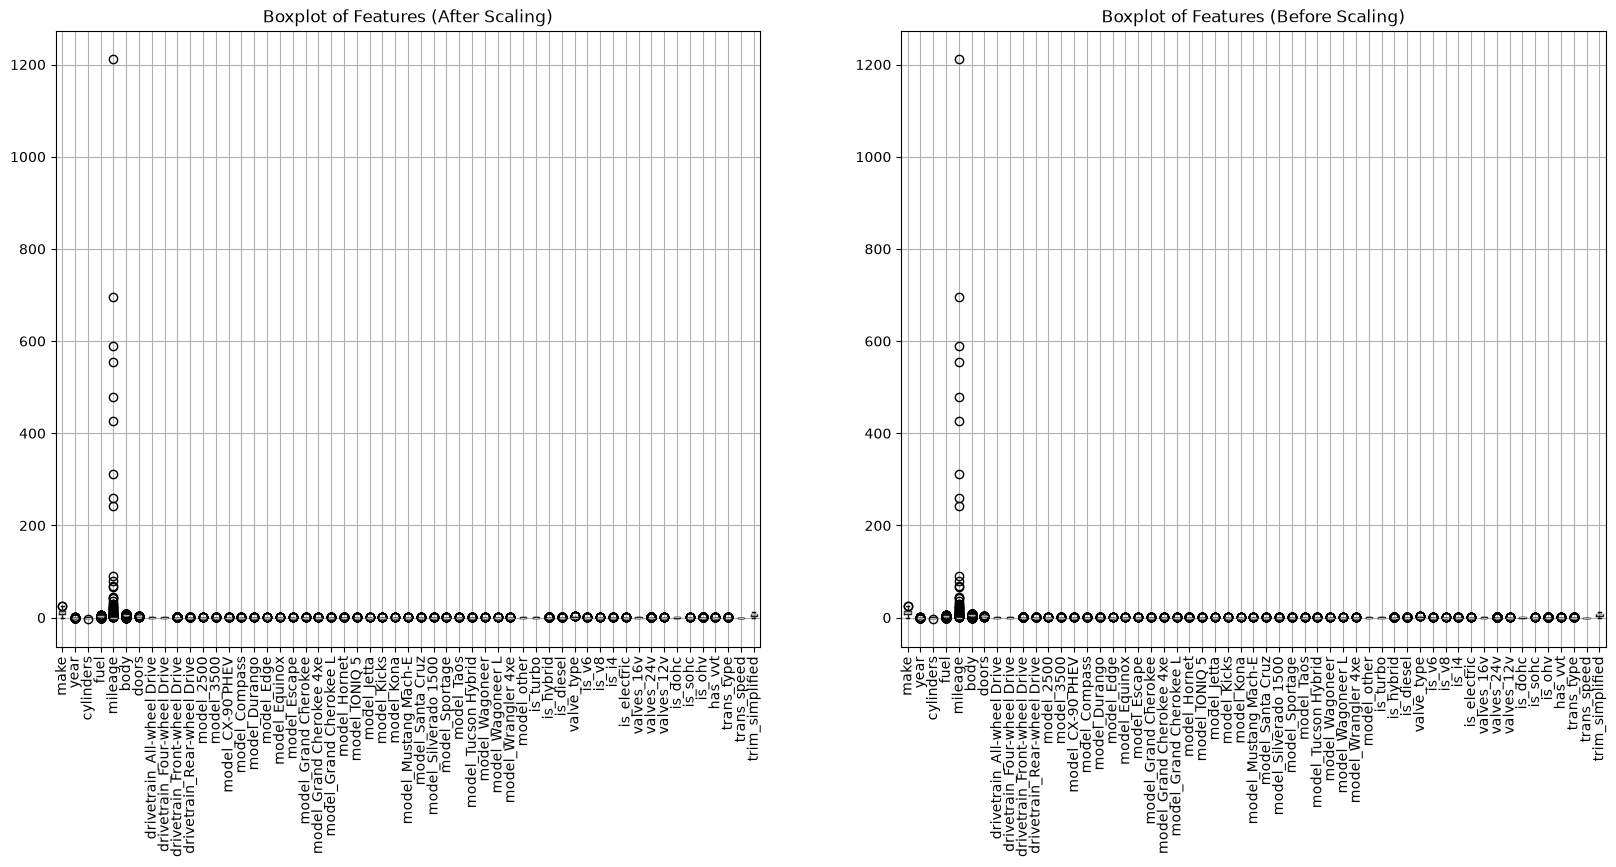

In [66]:
plt.figure(figsize=(20,8))
plt.subplot(121)
x_scaled.boxplot(figsize=(16, 6), rot=90)
plt.title("Boxplot of Features (After Scaling)")
plt.subplot(122)
x_scaled.boxplot(figsize=(16, 6), rot=90)
plt.title("Boxplot of Features (Before Scaling)");